<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day04_practice2_%EA%B2%80%EC%A6%9D%EA%B3%A1%EC%84%A0_%EC%A0%80%EC%9E%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
# 학습 곡선, 과적합 관찰, 모델 저장

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["axes.unicode_minus"] = False
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [29]:
# 셀 1. 데이터 준비 - (학습 / 검증 / 테스트)

import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

CSV_URL = "https://raw.githubusercontent.com/taehojo/deeplearning_4th/master/data/pima-indians-diabetes3.csv"
CSV_PATH = "pima-indians-diabetes3.csv"

def load_pima():
  import os
  if os.path.exists(CSV_PATH):
    print(f"로컬 파일 재사용: {CSV_PATH}")
    return pd.read_csv(CSV_PATH)

  try:
    df = pd.read_csv(CSV_URL)
    df.to_csv(CSV_PATH, index=False)
    print(f"다운로드 완료 -> {CSV_PATH} 저장 (다음 실행부턴 재사용)")
    return df
  except Exception as e:
    raise SystemExit(
        f"데이터 다운로드 실패: {e}\n"
    )

df = load_pima()

X = df.drop("diabetes", axis=1).values
y = df["diabetes"].values

# 1차 : 학습 / 검증 80% / 테스트 20%
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42, stratify=y
)

# 2차 : 학습 60% / 검증 20%
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.25,
    random_state=42, stratify=y_tmp
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # 평균·표준편차 계산 + 학습 데이터 표준화
X_val = scaler.transform(X_val)           # 학습 데이터 기준으로 검증 표준화
X_test = scaler.transform(X_test)         # 학습 데이터 기준으로 테스트 표준화

def to_loader(X, y, shuffle):
  ds = TensorDataset(
      torch.tensor(X, dtype=torch.float32),
      torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
  )
  return DataLoader(ds, batch_size=32, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, shuffle=True)
val_loader = to_loader(X_val, y_val, shuffle=False)
test_loader = to_loader(X_test, y_test, shuffle=False)

print(f"학습 {len(X_train)} / 검증 {len(X_val)} / 테스트 {len(X_test)}")
# 검증(val): 학습 '중간중간' 성적 확인 - 언제 멈출지, 어떤 설정이 나은지 결정
# 테스트(test): 모든 결정이 끝난 뒤 "딱 한 번" 최종 평가

로컬 파일 재사용: pima-indians-diabetes3.csv
학습 460 / 검증 154 / 테스트 154


In [30]:
# 셀 2. 일부러 큰 모델 - 과적합이 잘 보이게
model = nn.Sequential(
    nn.Linear(8, 16), nn.ReLU(),
    nn.Linear(16, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 1), nn.Sigmoid(),
)

loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [31]:
# 셀 3. 에폭마다 학습 loss와 검증 loss를 '둘 다' 기록

def evaluate(loader):
  model.eval() # 모델을 평가 모드로 전환
  total_loss, correct, n = 0.0, 0, 0
  with torch.no_grad():
    for xb, yb in loader:
      xb, yb = xb.to(device), yb.to(device)
      pred = model(xb)
      total_loss += loss_fn(pred, yb).item() * len(xb) # 전체 데이터셋의 평균 손실
      correct += ((pred > 0.5) == yb.bool()).sum().item() # 올바르게 예측된 샘플의 수
      n += len(xb) # 전체 샘플 수
  return total_loss / n, correct / n # 평균 손실, 평균 정확도

EPOCHS = 300
history = {"train": [], "val": []}
best_val, best_epoch = float("inf"), 0    # 양의 무한대 값으로 초기화, 최소값을 찾을 때 사용되는 기법

for epoch in range(EPOCHS):
  model.train() # 모델을 훈련 모드로 전환
  total = 0.0
  for xb, yb in train_loader: # 학습 데이터를 배치(batch) 단위로 가져온다
    xb, yb = xb.to(device), yb.to(device)
    loss = loss_fn(model(xb), yb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total += loss.item() * len(xb)

  train_loss = total / len(X_train) # 평균 손실
  val_loss, val_acc = evaluate(val_loader) # 평균 손실, 평균 정확도
  history["train"].append(train_loss)
  history["val"].append(val_loss)

  if val_loss < best_val:
    best_val = val_loss
    best_epoch = epoch + 1
    torch.save(model.state_dict(), "best_model.pt")
    print(f"best 갱신 epoch{best_epoch:3d} | train {train_loss:.4f} | val {val_loss:.4f} | val 정확도 {val_acc:.3f}")

  if (epoch + 1) % 50 == 0:
    print(f"epoch {epoch + 1:3d} | train {train_loss:.4f} | val {val_loss:.4f} | val 정확도 {val_acc:.3f}")

print(f"\n최고 검증 loss: {best_val:.4f}")


best 갱신 epoch  1 | train 0.6394 | val 0.6003 | val 정확도 0.649
best 갱신 epoch  2 | train 0.5785 | val 0.5425 | val 정확도 0.721
best 갱신 epoch  3 | train 0.5410 | val 0.5015 | val 정확도 0.740
best 갱신 epoch  4 | train 0.5176 | val 0.4831 | val 정확도 0.773
best 갱신 epoch  5 | train 0.4997 | val 0.4713 | val 정확도 0.786
best 갱신 epoch  6 | train 0.4820 | val 0.4592 | val 정확도 0.786
best 갱신 epoch  7 | train 0.4683 | val 0.4516 | val 정확도 0.773
best 갱신 epoch  8 | train 0.4517 | val 0.4481 | val 정확도 0.773
best 갱신 epoch 10 | train 0.4382 | val 0.4454 | val 정확도 0.779
best 갱신 epoch 12 | train 0.4252 | val 0.4430 | val 정확도 0.786
best 갱신 epoch 15 | train 0.4093 | val 0.4420 | val 정확도 0.786
epoch  50 | train 0.2631 | val 0.5934 | val 정확도 0.773
epoch 100 | train 0.0870 | val 1.3582 | val 정확도 0.734
epoch 150 | train 0.0170 | val 2.3766 | val 정확도 0.708
epoch 200 | train 0.0047 | val 4.1290 | val 정확도 0.721
epoch 250 | train 0.0018 | val 5.5297 | val 정확도 0.721
epoch 300 | train 0.0008 | val 5.7733 | val 정확도 0.721

최고 검

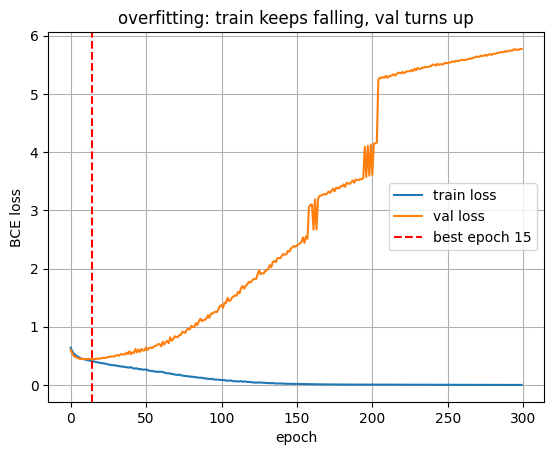

In [32]:
# 셀 4. 두 곡선 그리기 - 과적합을 눈으로

best_idx = best_epoch - 1
plt.plot(history["train"], label="train loss")
plt.plot(history["val"], label="val loss")
plt.axvline(best_idx, color="red", ls="--",
            label=f"best epoch {best_epoch}")

plt.xlabel("epoch"); plt.ylabel("BCE loss"); plt.legend(); plt.grid(True)
plt.title("overfitting: train keeps falling, val turns up")
plt.savefig("plot1_curves.png")
plt.show()

In [33]:
# 셀 5. 저장한 모델 불러오기 - state_dict

new_model = nn.Sequential(
    nn.Linear(8, 16), nn.ReLU(),
    nn.Linear(16, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 1), nn.Sigmoid(),
).to(device)

state = torch.load("best_model.pt", map_location=device)
new_model.load_state_dict(state)
new_model.eval()

last_loss, last_acc = evaluate(test_loader)
model = new_model
best_loss, best_acc = evaluate(test_loader)

print("\n---테스트(최종 채점) 비교---")
print(f"마지막 epoch 모델 : loss {last_loss:.4f} | 정확도 {last_acc:.4f}")
print(f"best(저장본) 모델 : loss {best_loss:.4f} | 정확도 {best_acc:.4f}")


---테스트(최종 채점) 비교---
마지막 epoch 모델 : loss 6.8342 | 정확도 0.6818
best(저장본) 모델 : loss 0.5097 | 정확도 0.7143
